In [1]:
# Run only if needed

!pip install pandas numpy matplotlib seaborn scikit-learn

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Online-Store-Orders.xlsx to Online-Store-Orders (1).xlsx


In [9]:
df = pd.read_excel("Online-Store-Orders.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [10]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicates: 0


In [11]:
df.drop_duplicates(inplace=True)

print(df.shape)

(1200, 14)


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df['PurchaseMonth'] = df['Date'].dt.month

df['PurchaseQuarter'] = df['Date'].dt.quarter

df['PurchaseDay'] = df['Date'].dt.day

df['Weekday'] = df['Date'].dt.dayofweek

df['WeekendOrder'] = np.where(
    df['Weekday'] >= 5,
    1,
    0
)

df['OrderValuePerItem'] = (
    df['TotalPrice'] /
    df['Quantity']
)

df['CartEfficiency'] = (
    df['Quantity'] /
    df['ItemsInCart']
)

df['DiscountUsed'] = np.where(
    df['CouponCode'].isna(),
    0,
    1
)

In [14]:
label_cols = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

encoder = LabelEncoder()

for col in label_cols:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

In [15]:
label_cols = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

encoder = LabelEncoder()

for col in label_cols:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

In [16]:
shipping_encoded = pd.get_dummies(
    df['ShippingAddress'],
    prefix='Address'
)

df = pd.concat(
    [df, shipping_encoded],
    axis=1
)

In [17]:
df_model = df.drop(
    columns=[
        'OrderID',
        'CustomerID',
        'TrackingNumber',
        'Date',
        'ShippingAddress'
    ]
)

df_model.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,PurchaseMonth,...,Address_989 Main St,Address_990 Main St,Address_991 Main St,Address_992 Main St,Address_993 Main St,Address_995 Main St,Address_996 Main St,Address_997 Main St,Address_998 Main St,Address_999 Main St
0,3,5,570.62,2,4,7,1,3,2853.10,1,...,False,False,False,False,False,False,False,False,False,False
1,4,2,151.35,4,4,3,1,4,302.70,8,...,False,False,False,False,False,False,False,False,False,False
2,6,5,550.68,1,0,8,0,0,2753.40,2,...,False,False,False,False,False,False,False,False,False,False
3,0,1,273.19,2,3,5,1,1,273.19,10,...,False,False,False,False,False,False,False,False,False,False
4,5,4,626.01,4,1,8,1,0,2504.04,5,...,False,False,False,False,False,False,False,False,False,False


In [18]:
print(
    "Number of Features:",
    df_model.shape[1]
)

Number of Features: 672


In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df_model
)

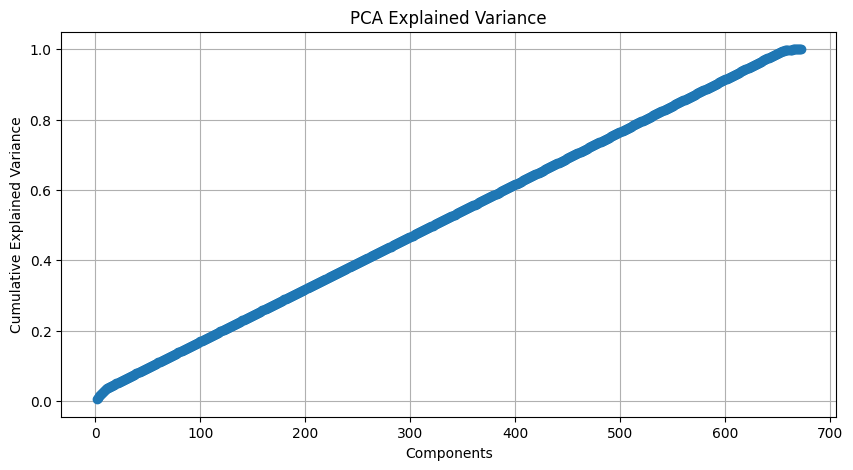

In [20]:
pca_test = PCA()

pca_test.fit(scaled_data)

cum_var = np.cumsum(
    pca_test.explained_variance_ratio_
)

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Components")

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.grid()

plt.show()

In [21]:
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

print(
    "Variance Retained:",
    round(
        pca.explained_variance_ratio_.sum()*100,
        2
    ),
    "%"
)

Variance Retained: 0.91 %


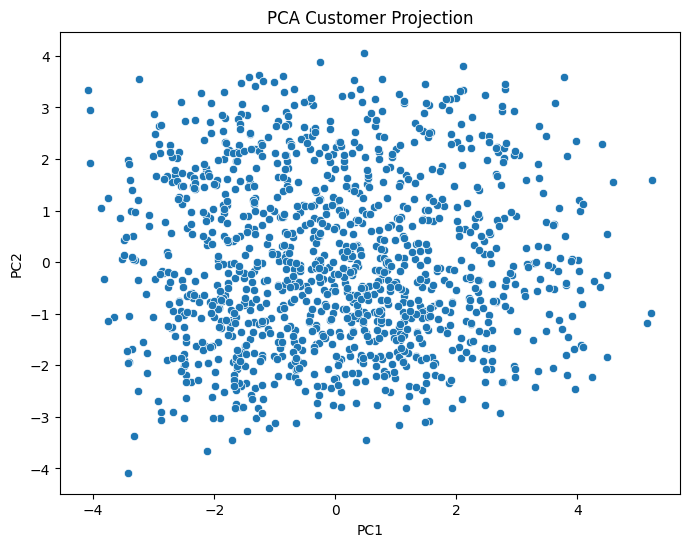

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df
)

plt.title(
    "PCA Customer Projection"
)

plt.show()

In [23]:
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(pca_df)

    wcss.append(
        km.inertia_
    )

In [24]:
scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(
        pca_df
    )

    score = silhouette_score(
        pca_df,
        labels
    )

    scores.append(score)

    print(
        f"K={k}  Score={score:.4f}"
    )

K=2  Score=0.3462
K=3  Score=0.3669
K=4  Score=0.3669
K=5  Score=0.3636
K=6  Score=0.3388
K=7  Score=0.3552
K=8  Score=0.3404
K=9  Score=0.3322
K=10  Score=0.3260


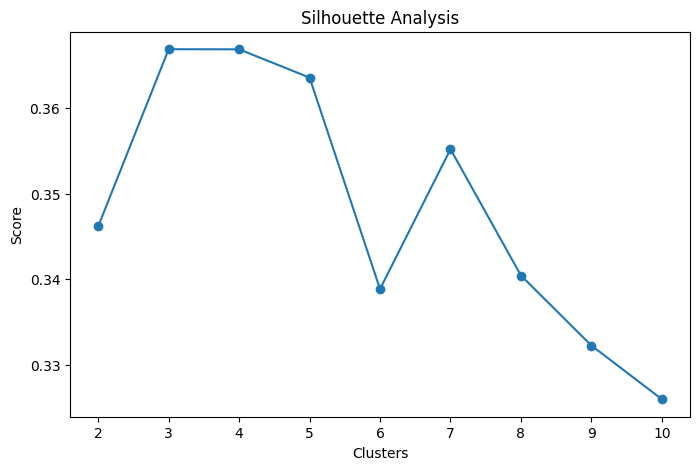

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.title(
    "Silhouette Analysis"
)

plt.xlabel(
    "Clusters"
)

plt.ylabel(
    "Score"
)

plt.show()

In [26]:
optimal_k = 4

In [27]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

clusters = kmeans.fit_predict(
    pca_df
)

df['Cluster'] = clusters

pca_df['Cluster'] = clusters

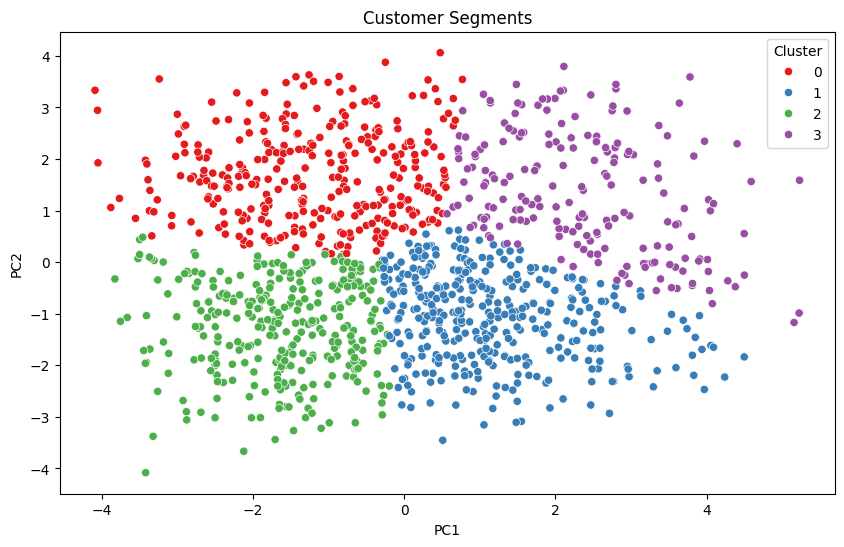

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title(
    "Customer Segments"
)

plt.show()

In [29]:
df['Cluster'].value_counts()

,count
Cluster,
1,372
0,318
2,315
3,195


In [30]:
persona = df.groupby(
    'Cluster'
)[
[
'Quantity',
'UnitPrice',
'TotalPrice',
'ItemsInCart',
'OrderValuePerItem'
]
].mean()

persona

,Quantity,UnitPrice,TotalPrice,ItemsInCart,OrderValuePerItem
Cluster,,,,,
0,2.518868,261.693270,572.832799,4.855346,261.693270
1,3.193548,474.016909,1438.567258,5.881720,474.016909
2,2.507937,181.134889,394.172857,5.088889,181.134889
3,3.876923,569.666974,2170.716205,6.394872,569.666974


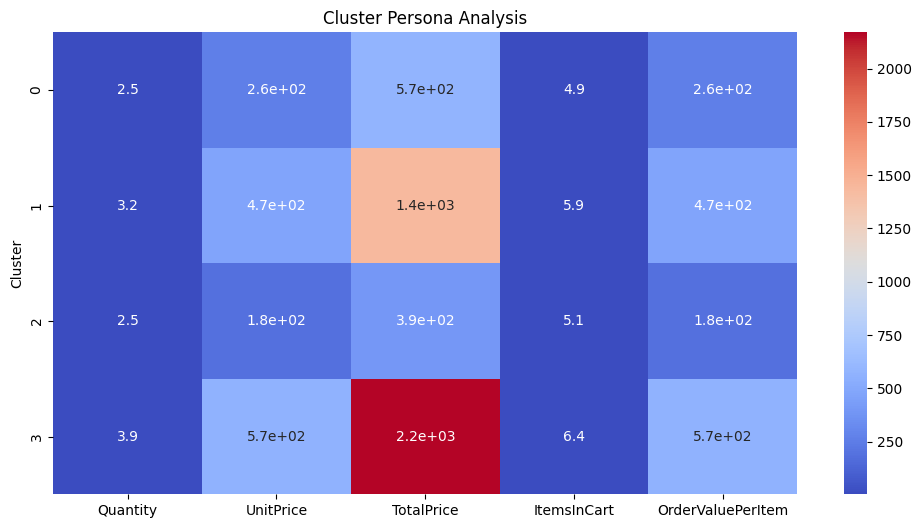

In [31]:
plt.figure(figsize=(12,6))

sns.heatmap(
    persona,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Cluster Persona Analysis"
)

plt.show()

In [32]:
for cluster in persona.index:

    print("\n")
    print("="*50)

    print(
        f"PERSONA {cluster}"
    )

    print("="*50)

    print(
        persona.loc[cluster]
    )



PERSONA 0
Quantity               2.518868
UnitPrice            261.693270
TotalPrice           572.832799
ItemsInCart            4.855346
OrderValuePerItem    261.693270
Name: 0, dtype: float64


PERSONA 1
Quantity                3.193548
UnitPrice             474.016909
TotalPrice           1438.567258
ItemsInCart             5.881720
OrderValuePerItem     474.016909
Name: 1, dtype: float64


PERSONA 2
Quantity               2.507937
UnitPrice            181.134889
TotalPrice           394.172857
ItemsInCart            5.088889
OrderValuePerItem    181.134889
Name: 2, dtype: float64


PERSONA 3
Quantity                3.876923
UnitPrice             569.666974
TotalPrice           2170.716205
ItemsInCart             6.394872
OrderValuePerItem     569.666974
Name: 3, dtype: float64


In [33]:
df.to_csv(
    "Customer_Segments_Output.csv",
    index=False
)

print(
    "Customer Segmentation Completed Successfully!"
)

Customer Segmentation Completed Successfully!
